Análise de Desempenho: Problema dos Missionários e Canibais (N)
N     | Status       | Passos   | Nós Acessados   | Tempo (s)    | Mem. Pico (KB)    
--------------------------------------------------------------------------------
1     | Resolvido    | 1        | 1               | 0.000062     | 2.91              
2     | Resolvido    | 5        | 8               | 0.000084     | 3.82              
3     | Resolvido    | 11       | 13              | 0.000148     | 3.68              

[3=3] IMPRIMINDO PASSOS DA SOLUÇÃO ÓTIMA:
---------------------------------------------------------------------------
ESTADO INICIAL:
Esq: [3M, 3C, Barco]  ~~~~~~~~~~  Dir: [0M, 0C]
---------------------------------------------------------------------------
PASSO 1: Barco --> (Indo) com 0M e 2C
Esq: [3M, 1C]  ~~~~~~~~~~  Dir: [0M, 2C, Barco]
---------------------------------------------------------------------------
PASSO 2: Barco <-- (Voltando) com 0M e 1C
Esq: [3M, 2C, Barco]  ~~~~~~~~~~  Dir: [0M, 1C]


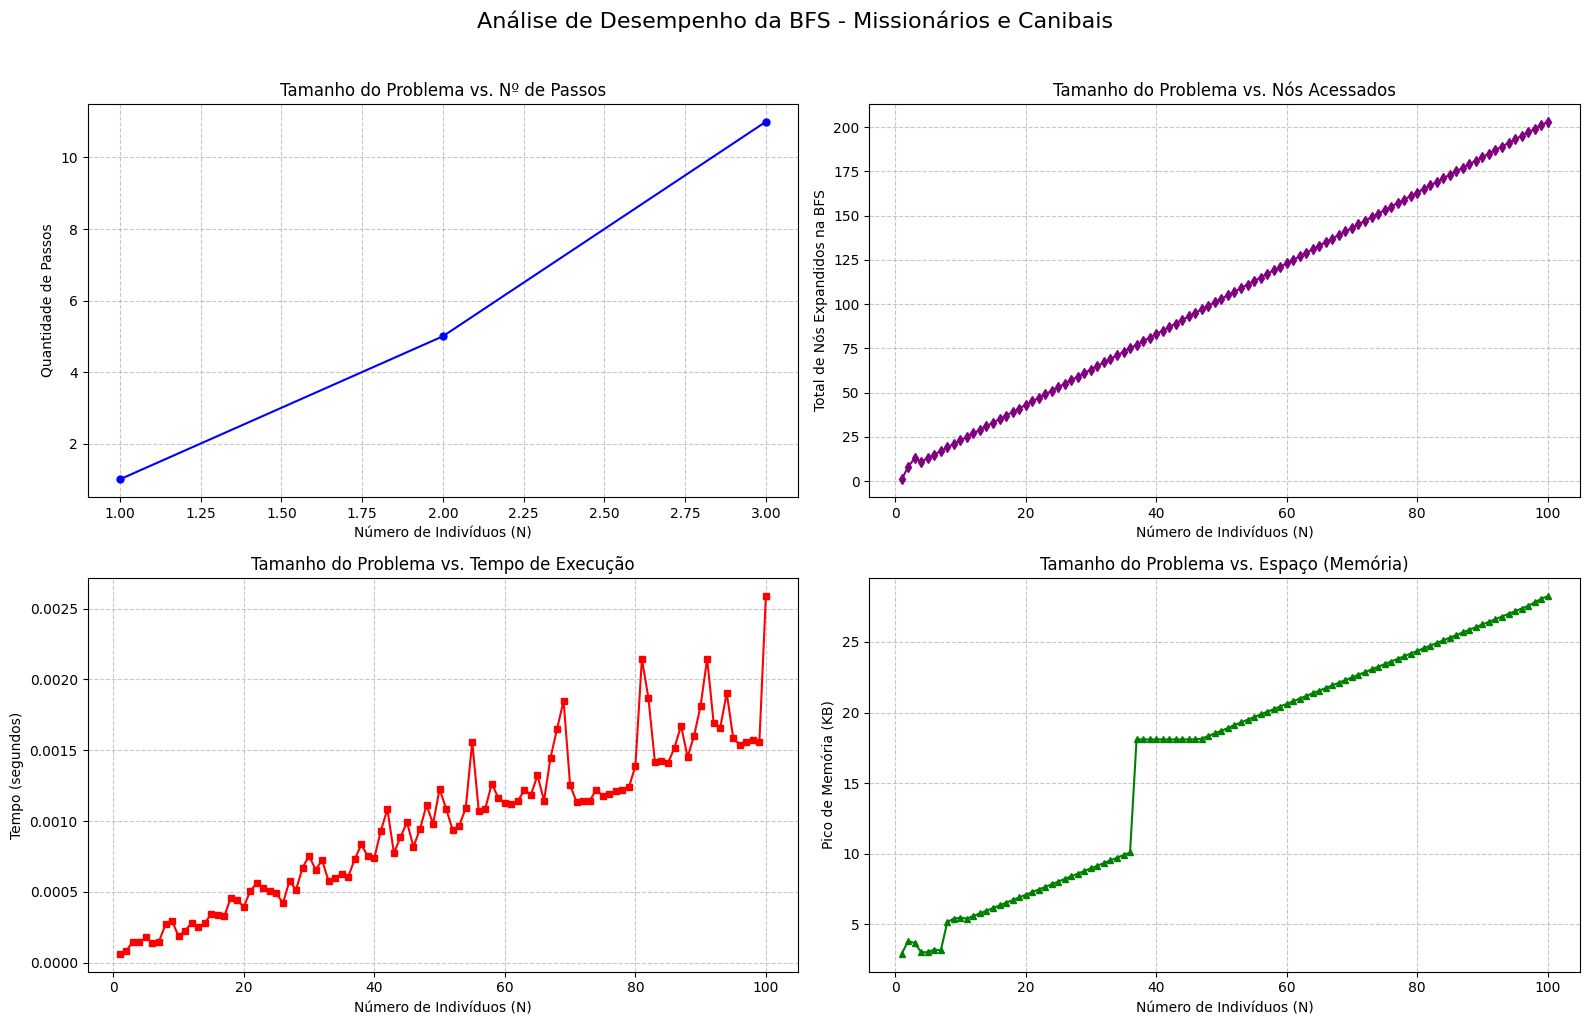

In [ ]:
import time
import tracemalloc
import numpy as np
import matplotlib.pyplot as plt
from collections import deque

class No:
    def __init__(self, estado, pai=None, acao=None):
        self.estado = estado
        self.pai = pai
        self.acao = acao

#formulação do problema conforme definido no livro
class ProblemaMissionariosCanibais:
    def __init__(self, N):
        self.N = N
        self.estado_inicial = (N, N, 1)
        self.acoes_possiveis = [(1, 0), (2, 0), (0, 1), (0, 2), (1, 1)]

    def teste_objetivo(self, estado):
        return estado == (0, 0, 0)

    def estado_valido(self, estado):
        m_esq, c_esq, _ = estado

        #confere se quantidades da esquerda estão dentro de 0..N.
        if not (0 <= m_esq <= self.N and 0 <= c_esq <= self.N):
            return False


        m_dir = self.N - m_esq
        c_dir = self.N - c_esq

        #se em um lado houver missionários mas os canibais forem maioria, é inválido
        if m_esq > 0 and m_esq < c_esq: return False
        if m_dir > 0 and m_dir < c_dir: return False

        return True

    #aqui calculo como vai ser o novo estado após uma ação
    def resultado(self, estado, acao):
        m_esq, c_esq, b_esq = estado
        m, c = acao
        #movimento do barco
        if b_esq == 1: return (m_esq - m, c_esq - c, 0)
        else: return (m_esq + m, c_esq + c, 1)

#algoritmo de busca BFS
def busca_em_largura_em_grafo(problema):
    nos_expandidos = 0 #contador para o número de nós acessados durante a busca
    no_inicial = No(problema.estado_inicial)

    if problema.teste_objetivo(no_inicial.estado):
        return no_inicial, nos_expandidos

    borda = deque([no_inicial])
    estados_borda = {no_inicial.estado}
    explorado = set()

    #itera enquanto houver nós na borda para explorar
    while borda:
        no_atual = borda.popleft() #retira na esquerda
        nos_expandidos += 1 #incrementa toda vez que remove um nó da borda para expansão
        estados_borda.remove(no_atual.estado)

        explorado.add(no_atual.estado) #bota na tabela hash o estado atual

        for acao in problema.acoes_possiveis:
            novo_estado = problema.resultado(no_atual.estado, acao)

            if problema.estado_valido(novo_estado):
                filho = No(novo_estado, pai=no_atual, acao=acao)

                #só explora nó que não foi explorado ainda ou que não está na borda
                if filho.estado not in explorado and filho.estado not in estados_borda:
                    if problema.teste_objetivo(filho.estado):
                        return filho, nos_expandidos #é o objetivo, retorna o nó e a quantidade de nós acessados

                    borda.append(filho) #não é o obj, vai para o final da borda
                    estados_borda.add(filho.estado)

    return None, nos_expandidos #retorna também o total de nós acessados quando não há solução (só para manter a consistência da coleta de dados)

#função para extrair o caminho da solução a partir do nó objetivo encontrado, começa pelo objetivo e vai voltando pelo nó pai
def extrair_caminho(no_objetivo):
    if no_objetivo is None: return None
    caminho = []
    atual = no_objetivo
    while atual is not None:
        caminho.append((atual.acao, atual.estado))
        atual = atual.pai
    return caminho[::-1]

#função do ChatGPT para imprimir o passo a passo da solução
def imprimir_passo_a_passo(caminho, N):
    print(f"\n[{N}=3] IMPRIMINDO PASSOS DA SOLUÇÃO ÓTIMA:")
    print("-" * 75)
    for i, passo in enumerate(caminho):
        acao, estado = passo
        m_esq, c_esq, b_esq = estado
        m_dir, c_dir = N - m_esq, N - c_esq
        if i == 0:
            print("ESTADO INICIAL:")
            print(f"Esq: [{m_esq}M, {c_esq}C, Barco]  ~~~~~~~~~~  Dir: [{m_dir}M, {c_dir}C]")
        else:
            m_acao, c_acao = acao
            direcao = "--> (Indo)" if b_esq == 0 else "<-- (Voltando)"
            print(f"PASSO {i}: Barco {direcao} com {m_acao}M e {c_acao}C")
            if b_esq == 1:
                print(f"Esq: [{m_esq}M, {c_esq}C, Barco]  ~~~~~~~~~~  Dir: [{m_dir}M, {c_dir}C]")
            else:
                print(f"Esq: [{m_esq}M, {c_esq}C]  ~~~~~~~~~~  Dir: [{m_dir}M, {c_dir}C, Barco]")
        print("-" * 75)
    print("\n")

#execução e gráficos
if __name__ == "__main__":
    max_N = 100 #variável para controlar o tamanho máximo do problema a ser testado

    lista_n, lista_passos, lista_tempos, lista_memoria, lista_nos = [], [], [], [], []

    print("Análise de Desempenho: Problema dos Missionários e Canibais (N)")
    print(f"{'N':<5} | {'Status':<12} | {'Passos':<8} | {'Nós Acessados':<15} | {'Tempo (s)':<12} | {'Mem. Pico (KB)':<18}")
    print("-" * 80)

    for n in range(1, max_N + 1):
        problema = ProblemaMissionariosCanibais(n)

        tracemalloc.start()
        inicio = time.perf_counter()

        #recebe nó e a quantidade de nós acessados
        no_solucao, nos_expandidos = busca_em_largura_em_grafo(problema)

        fim = time.perf_counter() #marca tempo final
        _, pico_memoria = tracemalloc.get_traced_memory() #le o pico de memória usado durante a execução
        tracemalloc.stop() #para de medir memória

        tempo_execucao = fim - inicio
        memoria_kb = pico_memoria / 1024 #converte para KB (para ficar mais legível)

        lista_n.append(n)
        lista_tempos.append(tempo_execucao)
        lista_memoria.append(memoria_kb)
        lista_nos.append(nos_expandidos)

        if no_solucao:
            caminho = extrair_caminho(no_solucao)
            passos = len(caminho) - 1
            lista_passos.append(passos)

            if n <= 10:
                print(f"{n:<5} | Resolvido    | {passos:<8} | {nos_expandidos:<15} | {tempo_execucao:<12.6f} | {memoria_kb:<18.2f}")
            if n == 3: imprimir_passo_a_passo(caminho, n)
        else:
            lista_passos.append(np.nan)
            print(f"{n:<5} | Sem solução  | {'-':<8} | {nos_expandidos:<15} | {tempo_execucao:<12.6f} | {memoria_kb:<18.2f}")

    #geração de gráficos
    fig, axs = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle('Análise de Desempenho da BFS - Missionários e Canibais', fontsize=16, y=1.02)

    #gráfico 1: N vs Passos
    axs[0, 0].plot(lista_n, lista_passos, marker='o', color='blue', linestyle='-', markersize=5)
    axs[0, 0].set_title('Tamanho do Problema vs. Nº de Passos')
    axs[0, 0].set_xlabel('Número de Indivíduos (N)')
    axs[0, 0].set_ylabel('Quantidade de Passos')
    axs[0, 0].grid(True, linestyle='--', alpha=0.7)

    #gráfico 2: N vs Nós Acessados
    axs[0, 1].plot(lista_n, lista_nos, marker='d', color='purple', linestyle='-', markersize=5)
    axs[0, 1].set_title('Tamanho do Problema vs. Nós Acessados')
    axs[0, 1].set_xlabel('Número de Indivíduos (N)')
    axs[0, 1].set_ylabel('Total de Nós Expandidos na BFS')
    axs[0, 1].grid(True, linestyle='--', alpha=0.7)

    #gráfico 3: N vs Tempo de Execução
    axs[1, 0].plot(lista_n, lista_tempos, marker='s', color='red', linestyle='-', markersize=5)
    axs[1, 0].set_title('Tamanho do Problema vs. Tempo de Execução')
    axs[1, 0].set_xlabel('Número de Indivíduos (N)')
    axs[1, 0].set_ylabel('Tempo (segundos)')
    axs[1, 0].grid(True, linestyle='--', alpha=0.7)

    #gráfico 4: N vs Memória
    axs[1, 1].plot(lista_n, lista_memoria, marker='^', color='green', linestyle='-', markersize=5)
    axs[1, 1].set_title('Tamanho do Problema vs. Espaço (Memória)')
    axs[1, 1].set_xlabel('Número de Indivíduos (N)')
    axs[1, 1].set_ylabel('Pico de Memória (KB)')
    axs[1, 1].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()